<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/runtime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import time
import subprocess
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from cellmender import denoise_count_matrix
import cellmender.utils as cm_utils

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# Runtime

pbmc8k dataset: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k, hgmm12k, tiny_cellbender, simulation1, custom
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
scar_env_cpu = "/home/jrich/miniconda3/envs/scar"
scar_env_gpu = "/home/jrich/miniconda3/envs/scar_gpu"

In [4]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name, "runtime")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name, "runtime")
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file
    expected_cells = 8381

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5

    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
else:
    raise ValueError(f"Dataset name {dataset_name} not recognized.")

min_genes = 0
min_cells = 0
umi_top_percentile_to_remove = 5
unique_genes_top_percentile_to_remove = 5
mt_gene_percentile_to_remove = 10
max_mt_percentage = None
n_top_genes = 2000
n_pcs = 25
n_neighbors = 20
leiden_resolution = 1.0

has_gpu = subprocess.call("nvidia-smi", stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL) == 0
max_threads = os.cpu_count()

tool_to_runtime_dict = {}

## Raw

In [ ]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", expected_cells=expected_cells, verbose=verbose)  # adds adata.obs["is_empty"]

if "celltype" not in adata_raw.obs.columns:
    adata_raw = cm_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)

11:16:43 - INFO - Loading adata from '/data/cellmender/notebooks/data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## cellmender

23:56:10 - INFO - Inferring gene ambient fractions.
23:56:10 - INFO - Added 'ambient_fraction' to adata.var.
23:56:10 - INFO - Inferring celltype profiles.


Logging to /data/cellmender/notebooks/data/pbmc8k/runtime/pbmc8k_cellmender_1threads.log


23:56:10 - INFO - Number of parameters in the cellmender model: 344,982 (alpha_i: 8,381, beta: 1, gamma_type: 67,048, p_k: 269,552)
23:56:13 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
23:56:13 - INFO - Performing Sparse EM with 1 Numba thread(s)
23:56:18 - INFO - EM Iter   1: ll=-320816728.716 mean_alpha=0.014645 beta=0.041803
23:56:20 - INFO - EM Iter   2: ll=-306379083.534 mean_alpha=0.014130 beta=0.041345
23:56:22 - INFO - EM Iter   3: ll=-306350789.603 mean_alpha=0.013710 beta=0.041051
23:56:24 - INFO - EM Iter   4: ll=-306331952.825 mean_alpha=0.013351 beta=0.040811
23:56:26 - INFO - EM Iter   5: ll=-306305487.237 mean_alpha=0.013015 beta=0.040592
23:56:28 - INFO - EM Iter   6: ll=-306270820.475 mean_alpha=0.012721 beta=0.040384
23:56:31 - INFO - EM Iter   7: ll=-306239460.016 mean_alpha=0.012459 beta=0.040185
23:56:33 - INFO - EM Iter   8: ll=-306212641.891 mean_alpha=0.012215 beta=0.039993
23:56:35 - INFO - EM Iter   9:

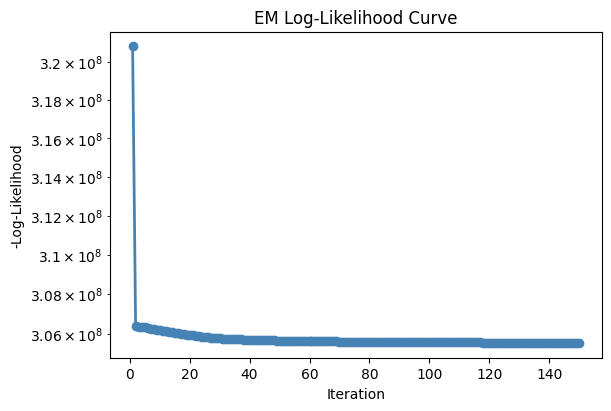

In [ ]:
threads = 1

if threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

cellmender_max_iter = 150
adata_path_cellmender = os.path.join(data_dir, f"pbmc8k_cellmender_{threads}threads.h5ad")
cellmender_log_file = os.path.join(data_dir, f"pbmc8k_cellmender_{threads}threads.log")

adata = adata_raw.copy()
if "celltype" not in adata.obs.columns:
    adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
start_time = time.perf_counter()
_ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=cellmender_max_iter, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, threads=threads, verbose=verbose, log_file=cellmender_log_file)
cellmender_runtime = time.perf_counter() - start_time
tool_to_runtime_dict[f"cellmender_{threads}threads"] = cellmender_runtime

cm_utils.plot_cellmender_likelihood_over_epochs(log_path=cellmender_log_file, show=True)

00:01:39 - INFO - Inferring gene ambient fractions.
00:01:39 - INFO - Added 'ambient_fraction' to adata.var.
00:01:39 - INFO - Inferring celltype profiles.


Logging to /data/cellmender/notebooks/data/pbmc8k/runtime/cellmender_16threads.log


00:01:39 - INFO - Number of parameters in the cellmender model: 344,982 (alpha_i: 8,381, beta: 1, gamma_type: 67,048, p_k: 269,552)
00:01:42 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
00:01:42 - INFO - Performing Sparse EM with 16 Numba thread(s)
00:01:44 - INFO - EM Iter   1: ll=-320816728.716 mean_alpha=0.014645 beta=0.041803
00:01:45 - INFO - EM Iter   2: ll=-306379083.534 mean_alpha=0.014130 beta=0.041345
00:01:47 - INFO - EM Iter   3: ll=-306350789.603 mean_alpha=0.013710 beta=0.041051
00:01:48 - INFO - EM Iter   4: ll=-306331952.825 mean_alpha=0.013351 beta=0.040811
00:01:49 - INFO - EM Iter   5: ll=-306305487.237 mean_alpha=0.013015 beta=0.040592
00:01:51 - INFO - EM Iter   6: ll=-306270820.475 mean_alpha=0.012721 beta=0.040384
00:01:52 - INFO - EM Iter   7: ll=-306239460.016 mean_alpha=0.012459 beta=0.040185
00:01:53 - INFO - EM Iter   8: ll=-306212641.891 mean_alpha=0.012215 beta=0.039993
00:01:55 - INFO - EM Iter   9

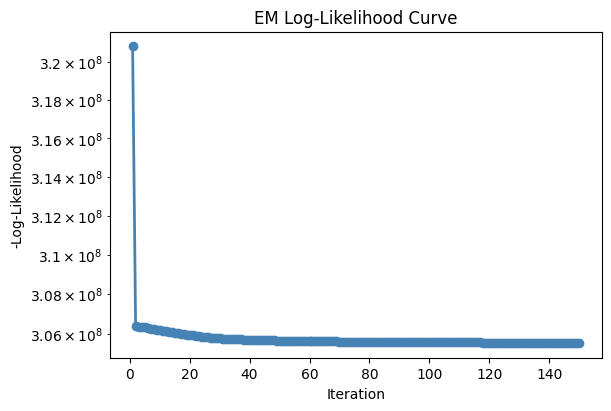

In [ ]:
threads = 16

if threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")
    
cellmender_max_iter = 150
adata_path_cellmender = os.path.join(data_dir, f"cellmender_{threads}threads.h5ad")
cellmender_log_file = os.path.join(data_dir, f"cellmender_{threads}threads.log")

adata = adata_raw.copy()
if "celltype" not in adata.obs.columns:
    adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
start_time = time.perf_counter()
_ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=cellmender_max_iter, beta=0.03, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=0.01, threads=threads, verbose=verbose, log_file=cellmender_log_file)
cellmender_runtime = time.perf_counter() - start_time
tool_to_runtime_dict[f"cellmender_{threads}threads"] = cellmender_runtime

cm_utils.plot_cellmender_likelihood_over_epochs(log_path=cellmender_log_file, show=True)

## CellBender (v0.3.0)

In [ ]:
use_cuda = False
threads = 1

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")
if not use_cuda and threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

epochs = 150
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""
input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellmender_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellmender_dir}/notebooks/data", "/data")

start_time = time.perf_counter()
!docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
     cellbender remove-background \
     --input {input_path} \
     --output {output_path} \
     --epochs {epochs} \
     --fpr 0.01 \
     --model full \
     {runtime}
cellbender_runtime = time.perf_counter() - start_time
dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
tool_to_runtime_dict[dict_key] = cellbender_runtime

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k/runtime/cellbender_cpu_1threads.h5 --epochs 150 --fpr 0.01 --model full --cpu-threads 1
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 7447dc7ef0)
cellbender:remove-background: 2025-11-23 08:05:04
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estimate

In [ ]:
use_cuda = False
threads = 16

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")
if not use_cuda and threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

epochs = 150
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""
input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellmender_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellmender_dir}/notebooks/data", "/data")

start_time = time.perf_counter()
!docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
     cellbender remove-background \
     --input {input_path} \
     --output {output_path} \
     --epochs {epochs} \
     --fpr 0.01 \
     --model full \
     {runtime}
cellbender_runtime = time.perf_counter() - start_time
dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
tool_to_runtime_dict[dict_key] = cellbender_runtime

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k/runtime/cellbender_cpu_16threads.h5 --epochs 150 --fpr 0.01 --model full --cpu-threads 16
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 12dd223dd0)
cellbender:remove-background: 2025-11-23 16:29:25
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estima

In [ ]:
use_cuda = True
threads = None

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")
if not use_cuda and threads > max_threads:
    SystemExit(f"Requested {threads} threads but only {max_threads} available.")

epochs = 150
runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
gpus = "--gpus all" if use_cuda else ""
input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
output_path = os.path.join(data_dir, f"cellbender_gpu.h5").replace(f"{cellmender_dir}/notebooks/data", "/data") if use_cuda else os.path.join(data_dir, f"cellbender_cpu_{threads}threads.h5").replace(f"{cellmender_dir}/notebooks/data", "/data")

start_time = time.perf_counter()
!docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
     cellbender remove-background \
     --input {input_path} \
     --output {output_path} \
     --epochs {epochs} \
     --fpr 0.01 \
     --model full \
     {runtime}
cellbender_runtime = time.perf_counter() - start_time
dict_key = f"cellbender_{'gpu' if use_cuda else f'cpu_{threads}threads'}"
tool_to_runtime_dict[dict_key] = cellbender_runtime

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k/runtime/cellbender_gpu.h5 --epochs 150 --fpr 0.01 --model full --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 87dc8c41ea)
cellbender:remove-background: 2025-11-23 18:38:21
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k/runtime/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estimated to have <= 0.1 b

## SoupX (v1.6.2)

In [12]:
adata_soupx_obs_csv = f"{data_dir}/soupx_obs.csv"
if not os.path.exists(adata_soupx_obs_csv):
    adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
    adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

soupx_out_prefix = os.path.join(data_dir, f"soupX")

start_time = time.perf_counter()
!docker run --rm \
    -w /home/ruser/work \
    -v {cellmender_dir}:{rver_docker_workspace} \
    josephrich98/cellmender_tutorials:soupx.0.1.0 \
    Rscript {rver_docker_workspace}/scripts/run_soupx.R \
        {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
        {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
        {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
        leiden
soupx_runtime = time.perf_counter() - start_time
tool_to_runtime_dict["soupx"] = soupx_runtime

Loading data from: /home/ruser/work/cellmender/notebooks/data/pbmc8k/runtime/matrix_tar_files 
Loading raw count data
Loading cell-only count data
Loading extra analysis data where available
Assigning clusters...
Estimating contamination fraction...
814 genes passed tf-idf cut-off and 350 soup quantile filter.  Taking the top 100.
Using 1100 independent estimates of rho.
Estimated global rho of 0.07
Adjusting counts...
Expanding counts from 18 clusters to 8381 cells.
Writing output matrices...
Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you
NULL
✅ SoupX completed successfully.


## DecontX (v1.8.0)

In [12]:
decontx_out_prefix = os.path.join(data_dir, f"decontX")

start_time = time.perf_counter()
!docker run --rm \
    -w /home/ruser/work \
    -v {cellmender_dir}:{rver_docker_workspace} \
    josephrich98/cellmender_tutorials:decontx.0.1.0 \
    Rscript {rver_docker_workspace}/scripts/run_decontx.R \
        {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
        {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
        {sequencing_technology} \
        {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)} \
        --dont_prepend_sample_to_barcodes
decontx_runtime = time.perf_counter() - start_time
tool_to_runtime_dict["decontx"] = decontx_runtime

📦 Starting DecontX pipeline...
Raw matrix dir:  /home/ruser/work/cellmender/notebooks/data/pbmc8k/runtime/matrix_tar_files/raw_gene_bc_matrices/GRCh38 
Filtered matrix dir:  /home/ruser/work/cellmender/notebooks/data/pbmc8k/runtime/matrix_tar_files/filtered_gene_bc_matrices/GRCh38 
Sequencing technology:  10XV2 
Importing filtered CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: GRCh38
Importing raw CellRanger matrix for 10XV2...
Metrics summary file (metrics_summary.csv) not found for sample: GRCh38
Standardizing cell and gene names...
Running decontX denoising...
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Sun Nov 23 19:00:55 2025 .. Analyzing all cells
Sun Nov 23 19:00:55 2025 .... Generating UMAP and estimating cell types
Sun Nov 23 19:01:16 2025 .... Estimating contamination
Sun Nov 23 19:01:18 2025 ...... Completed iteration: 10 | converge: 0.02928
Sun Nov 23 

## scAR (v0.7.0)

In [ ]:
%env MPLBACKEND=
use_cuda = False

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")

epochs = 150
adata_path_scar = os.path.join(data_dir, f"scar_gpu.h5ad") if use_cuda else os.path.join(data_dir, f"scar_cpu_{threads}threads.h5ad")

runtime = "--cuda" if use_cuda else ""
conda_run_flag = "-p" if "/" in scar_env_cpu else "-n"
start_time = time.perf_counter()
!conda run {conda_run_flag} {scar_env_cpu} \
     python {cellmender_dir}/scripts/run_scar.py \
     -r {raw_tar_file_dir} \
     -f {filtered_tar_file_dir} \
     -o {adata_path_scar} \
     {runtime} \
     --epochs {epochs}
scar_runtime = time.perf_counter() - start_time
dict_key = f"scar_{'gpu' if use_cuda else 'cpu'}"
tool_to_runtime_dict[dict_key] = scar_runtime

env: MPLBACKEND=
Loading data...
Preprocessing data...
Setting up AnnData for scAR...
Running scAR...

Training:   0%|                                        | 0/150 [00:00<?, ?it/s]
                                                                               

Training: 100%|█████████████| 150/150 [20:29<00:00,  8.20s/it, Loss=4.2517e+03]
Performing inference...
Saving results...

2025-11-23 11:02:46|INFO|setup_anndata|Use all 261019 droplets.
2025-11-23 11:02:47|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
2025-11-23 11:03:45|INFO|setup_anndata|Iteration: 1
2025-11-23 11:04:44|INFO|setup_anndata|Iteration: 2
2025-11-23 11:05:42|INFO|setup_anndata|Iteration: 3
2025-11-23 11:05:42|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2025-11-23 11:05:43|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
2025-11-23 11:05:45|INFO|model|cpu will be used.
2025-11-23 11:05:45|INFO|model|Found ambient p

In [13]:
%env MPLBACKEND=
use_cuda = True

if use_cuda and not has_gpu:
     SystemExit("CUDA requested but no GPU available.")

epochs = 150
adata_path_scar = os.path.join(data_dir, f"scar_gpu.h5ad") if use_cuda else os.path.join(data_dir, f"scar_cpu_{threads}threads.h5ad")

runtime = "--cuda" if use_cuda else ""
conda_run_flag = "-p" if "/" in scar_env_gpu else "-n"
start_time = time.perf_counter()
!conda run {conda_run_flag} {scar_env_gpu} \
     python {cellmender_dir}/scripts/run_scar.py \
     -r {raw_tar_file_dir} \
     -f {filtered_tar_file_dir} \
     -o {adata_path_scar} \
     {runtime} \
     --epochs {epochs}
scar_runtime = time.perf_counter() - start_time
dict_key = f"scar_{'gpu' if use_cuda else 'cpu'}"
tool_to_runtime_dict[dict_key] = scar_runtime

env: MPLBACKEND=
Loading data...
Preprocessing data...
Setting up AnnData for scAR...
Running scAR...

Training:   0%|          | 0/150 [00:00<?, ?it/s]
                                                 

Training: 100%|██████████| 150/150 [08:51<00:00,  3.54s/it, Loss=4.2425e+03]
Performing inference...
Saving results...

2025-11-24 11:33:47|INFO|setup_anndata|Use all 261019 droplets.
2025-11-24 11:33:48|INFO|setup_anndata|Estimating ambient profile for ['Gene Expression']...
2025-11-24 11:34:54|INFO|setup_anndata|Iteration: 1
2025-11-24 11:36:07|INFO|setup_anndata|Iteration: 2
2025-11-24 11:37:05|INFO|setup_anndata|Iteration: 3
2025-11-24 11:37:05|INFO|setup_anndata|Estimated ambient profile for Gene Expression saved in adata.uns
2025-11-24 11:37:05|INFO|setup_anndata|Estimated ambient profile for all features saved in adata.uns
2025-11-24 11:37:09|INFO|model|cuda will be used.
2025-11-24 11:37:09|INFO|model|Found ambient profile in AnnData.uns['ambient_profile_all']
2025-11-24 11:37:

In [ ]:
# convert to minutes
tool_to_runtime_minutes_dict = {k: v / 60 for k, v in tool_to_runtime_dict.items()}
print(tool_to_runtime_minutes_dict)

{'cellmender_1threads': 5.486083099603032, 'cellmender_16threads': 3.359511807203914, 'cellbender_cpu_1threads': 504.35386805809105, 'cellbender_cpu_16threads': 128.92702953227175, 'cellbender_gpu': 22.02172445510514, 'soupx': 1.6098512041382491, 'decontx': 2.1877690135035666, 'scar_cpu': 24.54572350685485, 'scar_gpu': 13.524172533024103}


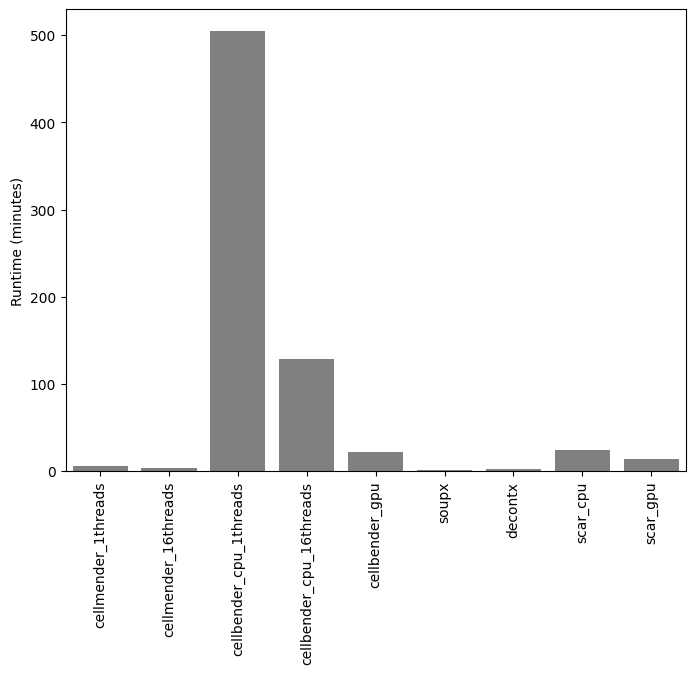

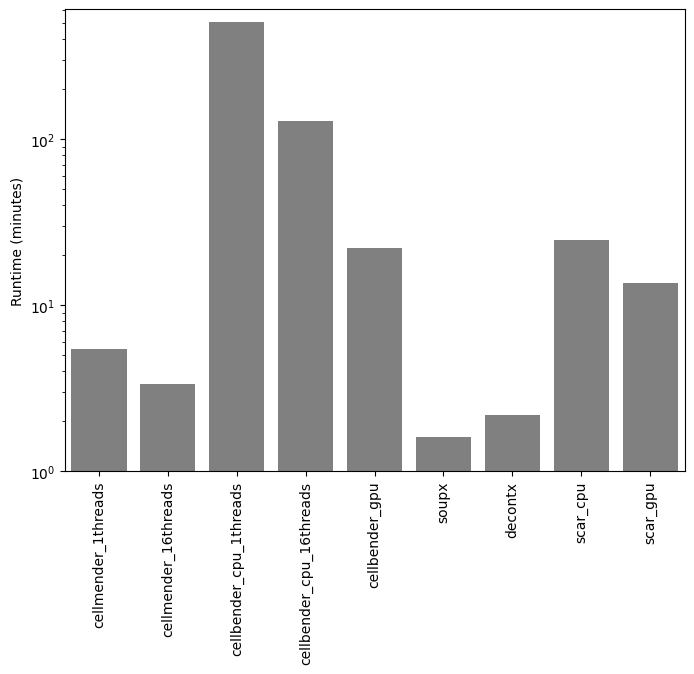

In [27]:
def plot_runtime_comparison(tool_to_runtime_minutes_dict, log=False, out_path=None):
    plt.figure(figsize=(8,6))
    sns.barplot(x=list(tool_to_runtime_minutes_dict.keys()), y=list(tool_to_runtime_minutes_dict.values()), color="gray")
    plt.xticks(rotation=90)
    plt.ylabel("Runtime (minutes)")
    if log:
        plt.ylim(1, max(tool_to_runtime_minutes_dict.values()) * 1.2)
        plt.yscale("log")
    if out_path:
        plt.savefig(out_path)
    plt.show()

plot_runtime_comparison(tool_to_runtime_minutes_dict, out_path=os.path.join(out_dir, "runtime_comparison.png"))
plot_runtime_comparison(tool_to_runtime_minutes_dict, log=True, out_path=os.path.join(out_dir, "runtime_comparison_log.png"))